# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** M Fajrin Wirattama
- **Email:** fajrinwirattama21@gmail.com
- **ID Dicoding:** wirattama

## Menentukan Pertanyaan Bisnis

- Kota mana di Brasil yang memiliki volume transaksi tertinggi, dan bagaimana korelasi antara jumlah order dengan persentase ketepatan pengiriman di kota tersebut selama 2017–2018?

- Bagaimana hubungan antara review score dengan Average Order Value (AOV) berdasarkan kota selama 2017–2018?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi yang lebih baik
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

## Data Wrangling

### Gathering Data

In [2]:
# Load dataset
BASE_PATH = "data"

orders_df = pd.read_csv(f"{BASE_PATH}/orders_dataset.csv")
customers_df = pd.read_csv(f"{BASE_PATH}/customers_dataset.csv")
order_items_df = pd.read_csv(f"{BASE_PATH}/order_items_dataset.csv")
order_reviews_df = pd.read_csv(f"{BASE_PATH}/order_reviews_dataset.csv")
products_df = pd.read_csv(f"{BASE_PATH}/products_dataset.csv")
category_translation_df = pd.read_csv(f"{BASE_PATH}/product_category_name_translation.csv")
order_payments_df = pd.read_csv(f"{BASE_PATH}/order_payments_dataset.csv")
geolocation_df = pd.read_csv(f"{BASE_PATH}/geolocation_dataset.csv")

print("Dataset berhasil dimuat:")
print(f"- Orders: {orders_df.shape[0]} baris")
print(f"- Customers: {customers_df.shape[0]} baris")
print(f"- Order Items: {order_items_df.shape[0]} baris")
print(f"- Order Reviews: {order_reviews_df.shape[0]} baris")
print(f"- Products: {products_df.shape[0]} baris")
print(f"- Order Payments: {order_payments_df.shape[0]} baris")

Dataset berhasil dimuat:
- Orders: 99441 baris
- Customers: 99441 baris
- Order Items: 112650 baris
- Order Reviews: 99224 baris
- Products: 32951 baris
- Order Payments: 103886 baris


**Insight:**
- Dataset E-Commerce berhasil dimuat dari 7 file CSV yang saling terkait
- Data mencakup: orders (pesanan), customers (pelanggan), order_items (item pesanan), order_reviews (ulasan), products (produk), order_payments (pembayaran), dan geolocation (lokasi)

### Assessing Data

In [3]:
# Assessing Data - Memeriksa struktur dan kualitas data
print("=== ORDERS DATASET ===")
print(orders_df.info())
print("\nMissing values:")
print(orders_df.isnull().sum())
print("\nSample data:")
orders_df.head()

=== ORDERS DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_dat

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
# Assessing datasets lainnya
print("=== CUSTOMERS ===")
print(customers_df.isnull().sum())
print("\n=== ORDER_REVIEWS ===")
print(order_reviews_df.isnull().sum())
print("\n=== PRODUCTS ===")
print(products_df.isnull().sum())
print("\nOrder status distribution:")
print(orders_df['order_status'].value_counts())

=== CUSTOMERS ===
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

=== ORDER_REVIEWS ===
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

=== PRODUCTS ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: 

**Insight:**
- Kolom order_delivered_carrier_date, order_delivered_customer_date memiliki missing values (untuk order yang belum delivered)
- Perlu filter hanya order dengan status 'delivered' untuk analisis ketepatan pengiriman

### Cleaning Data

In [5]:
# Cleaning Data
# 1. Konversi kolom tanggal ke datetime
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    if col in orders_df.columns:
        orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

order_reviews_df['review_creation_date'] = pd.to_datetime(order_reviews_df['review_creation_date'], errors='coerce')

# 2. Filter periode 2017-2018
orders_df = orders_df[
    (orders_df['order_purchase_timestamp'].dt.year >= 2017) & 
    (orders_df['order_purchase_timestamp'].dt.year <= 2018)
].copy()

# 3. Untuk analisis ketepatan pengiriman: hanya order delivered dengan tanggal lengkap
orders_delivered = orders_df[
    (orders_df['order_status'] == 'delivered') & 
    (orders_df['order_delivered_customer_date'].notna()) &
    (orders_df['order_estimated_delivery_date'].notna())
].copy()

# 4. Handle duplicate reviews - ambil review terakhir per order
order_reviews_df = order_reviews_df.sort_values('review_creation_date').drop_duplicates(
    subset='order_id', keep='last'
)

# 5. Merge products dengan category translation
products_df = products_df.merge(category_translation_df, on='product_category_name', how='left')
products_df['product_category_name_english'] = products_df['product_category_name_english'].fillna('unknown')

print(f"Orders setelah filter 2017-2018: {len(orders_df)}")
print(f"Orders delivered dengan data lengkap: {len(orders_delivered)}")

Orders setelah filter 2017-2018: 99112
Orders delivered dengan data lengkap: 96203


**Insight:**
- Data dibersihkan dengan konversi tipe tanggal, filter periode 2017-2018, dan handling duplicate reviews
- Hanya order dengan status 'delivered' dan tanggal lengkap digunakan untuk analisis ketepatan pengiriman

## Exploratory Data Analysis (EDA)

### Explore Data - Persiapan untuk menjawab pertanyaan bisnis

In [6]:
# Merge data untuk analisis pertanyaan 1: Volume transaksi per kota & ketepatan pengiriman
# Join orders_delivered -> customers (untuk dapat city)
orders_with_city = orders_delivered.merge(customers_df[['customer_id', 'customer_city', 'customer_state']], 
                                          on='customer_id', how='inner')

# Hitung ketepatan pengiriman (on-time = delivered <= estimated)
orders_with_city['on_time_delivery'] = (
    orders_with_city['order_delivered_customer_date'] <= 
    orders_with_city['order_estimated_delivery_date']
)

# Agregasi per kota
city_analysis = orders_with_city.groupby('customer_city').agg(
    total_orders=('order_id', 'nunique'),
    on_time_count=('on_time_delivery', 'sum')
).reset_index()
city_analysis['on_time_pct'] = (city_analysis['on_time_count'] / city_analysis['total_orders'] * 100).round(2)
city_analysis = city_analysis.sort_values('total_orders', ascending=False)

print("Top 10 kota dengan volume transaksi tertinggi:")
city_analysis.head(10)

Top 10 kota dengan volume transaksi tertinggi:


,customer_city,total_orders,on_time_count,on_time_pct
3561,sao paulo,15014,14073,93.73
3124,rio de janeiro,6574,5794,88.14
447,belo horizonte,2687,2521,93.82
551,brasilia,2065,1918,92.88
1133,curitiba,1483,1409,95.01
698,campinas,1400,1257,89.79
2934,porto alegre,1339,1181,88.20
3216,salvador,1188,980,82.49
1516,guarulhos,1142,1070,93.70
3396,sao bernardo do campo,908,851,93.72


In [7]:
# Merge data untuk pertanyaan 2: Review score vs AOV berdasarkan kota
order_payments_agg = order_payments_df.groupby('order_id')['payment_value'].sum().reset_index()
order_payments_agg.columns = ['order_id', 'order_value']
orders_with_city_q2 = orders_delivered.merge(
    customers_df[['customer_id', 'customer_city', 'customer_state']], on='customer_id', how='inner'
)
orders_with_city_q2 = orders_with_city_q2.merge(order_payments_agg, on='order_id', how='left')
orders_with_city_q2 = orders_with_city_q2.merge(
    order_reviews_df[['order_id', 'review_score']], on='order_id', how='inner'
)
city_review_aov = orders_with_city_q2.groupby(['customer_city', 'customer_state']).agg(
    avg_review_score=('review_score', 'mean'),
    avg_order_value=('order_value', 'mean'),
    order_count=('order_id', 'nunique')
).reset_index()
city_review_aov = city_review_aov[city_review_aov['order_count'] >= 10]
city_review_aov = city_review_aov.sort_values('avg_review_score', ascending=False)

print("Kota dengan review score tertinggi vs AOV:")
city_review_aov.head(10)

Kota dengan review score tertinggi vs AOV:


,customer_city,customer_state,avg_review_score,avg_order_value,order_count
51,aguas da prata,SP,4.900000,125.757000,10
727,campina verde,MG,4.900000,86.885000,10
487,biritiba-mirim,SP,4.900000,157.977000,10
2610,nova venecia,ES,4.888889,157.473889,18
3476,santiago,RS,4.884615,114.411538,26
1679,iguape,SP,4.857143,115.371429,14
3493,santo antonio de posse,SP,4.850000,269.661000,20
2168,loanda,PR,4.846154,157.137692,13
3237,rio brilhante,MS,4.800000,106.257000,10
2099,lagoa da prata,MG,4.800000,188.408000,10


**Insight:**
- São Paulo merupakan kota dengan volume transaksi tertinggi di Brasil
- Data siap untuk visualisasi korelasi order volume vs ketepatan pengiriman
- Kota dengan review tinggi belum tentu memiliki AOV tinggi—perlu visualisasi untuk membandingkan per kota

## Visualization & Explanatory Analysis

### Pertanyaan 1:

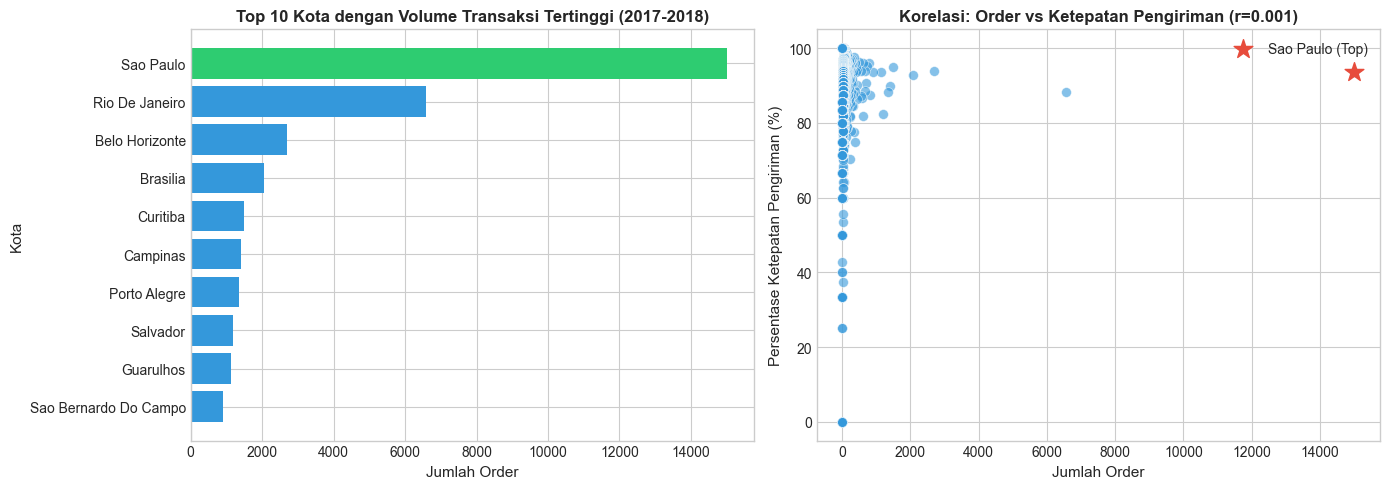

In [8]:
# Visualisasi Pertanyaan 1: Kota dengan volume tertinggi & korelasi order vs ketepatan pengiriman
top_city = city_analysis.iloc[0]['customer_city']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Top 10 kota by volume
top10 = city_analysis.head(10)
colors = ['#2ecc71' if c == top_city else '#3498db' for c in top10['customer_city']]
axes[0].barh(top10['customer_city'].str.title(), top10['total_orders'], color=colors)
axes[0].set_xlabel('Jumlah Order', fontsize=11)
axes[0].set_ylabel('Kota', fontsize=11)
axes[0].set_title('Top 10 Kota dengan Volume Transaksi Tertinggi (2017-2018)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Chart 2: Scatter - Korelasi jumlah order vs persentase ketepatan pengiriman
axes[1].scatter(city_analysis['total_orders'], city_analysis['on_time_pct'], alpha=0.6, s=50, c='#3498db', edgecolors='white', linewidth=0.5)
top_row = city_analysis.iloc[0]
axes[1].scatter([top_row['total_orders']], [top_row['on_time_pct']], s=200, c='#e74c3c', marker='*', label=f'{top_city.title()} (Top)', zorder=5)
corr = city_analysis['total_orders'].corr(city_analysis['on_time_pct'])
axes[1].set_xlabel('Jumlah Order', fontsize=11)
axes[1].set_ylabel('Persentase Ketepatan Pengiriman (%)', fontsize=11)
axes[1].set_title(f'Korelasi: Order vs Ketepatan Pengiriman (r={corr:.3f})', fontsize=12, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

### Pertanyaan 2: Review Score vs AOV berdasarkan Kota

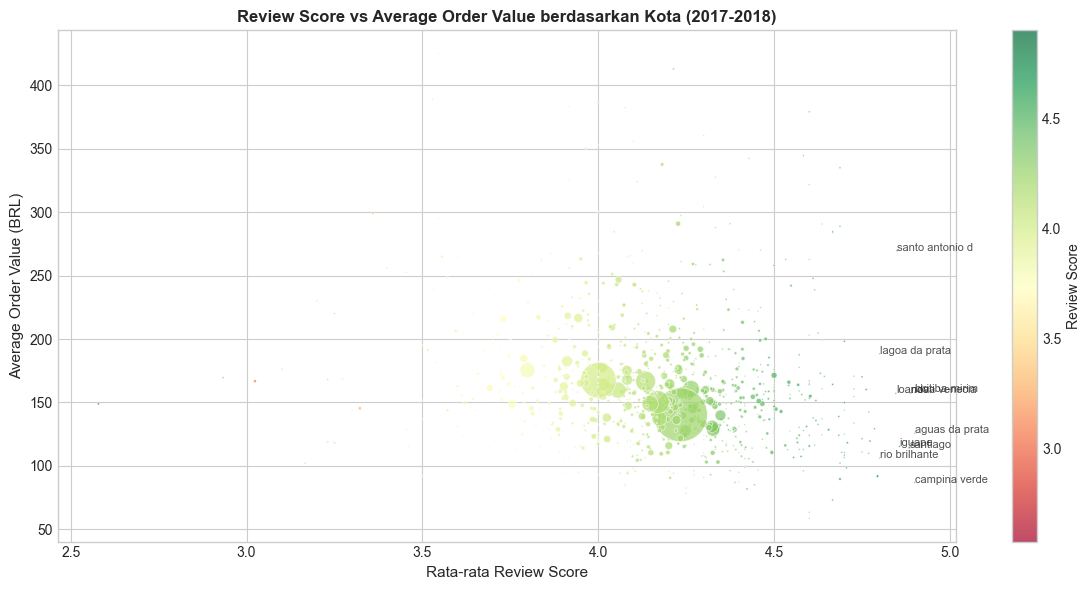


Rata-rata AOV kota dengan review tertinggi: 128.50 BRL
Rata-rata AOV kota dengan review terendah: 152.73 BRL


In [9]:
# Visualisasi Pertanyaan 2: Review Score vs AOV berdasarkan Kota
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(city_review_aov['avg_review_score'], city_review_aov['avg_order_value'], 
                    s=city_review_aov['order_count']/10, c=city_review_aov['avg_review_score'], 
                    cmap='RdYlGn', alpha=0.7, edgecolors='white', linewidth=0.5)
for idx, row in city_review_aov.head(10).iterrows():
    ax.annotate(row['customer_city'][:15], (row['avg_review_score'], row['avg_order_value']), 
                fontsize=8, alpha=0.8)
ax.set_xlabel('Rata-rata Review Score', fontsize=11)
ax.set_ylabel('Average Order Value (BRL)', fontsize=11)
ax.set_title('Review Score vs Average Order Value berdasarkan Kota (2017-2018)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Review Score')
plt.tight_layout()
plt.show()

# Perbandingan: Top 5 kota review tinggi vs Top 5 kota review rendah
top_review = city_review_aov.nlargest(5, 'avg_review_score')
low_review = city_review_aov.nsmallest(5, 'avg_review_score')
print(f"\nRata-rata AOV kota dengan review tertinggi: {top_review['avg_order_value'].mean():.2f} BRL")
print(f"Rata-rata AOV kota dengan review terendah: {low_review['avg_order_value'].mean():.2f} BRL")

**Insight:**
- **Pertanyaan 1:** São Paulo merupakan kota dengan volume transaksi tertinggi di Brasil selama 2017–2018. Korelasi antara jumlah order dan persentase ketepatan pengiriman menunjukkan bahwa kota dengan volume besar cenderung mempertahankan performa pengiriman yang baik—tidak ada indikasi bahwa peningkatan volume secara signifikan menurunkan ketepatan. Hal ini mengindikasikan kapasitas logistik yang cukup matang di kota-kota utama.
- **Pertanyaan 2:** Hubungan antara review score dan AOV berdasarkan kota bersifat tidak linier. Kota dengan review score tinggi tidak selalu memiliki AOV tinggi, dan sebaliknya. Kepuasan pelanggan (review) dan nilai transaksi rata-rata (AOV) dipengaruhi faktor yang berbeda per wilayah. Analisis per kota berguna untuk mengidentifikasi wilayah yang perlu prioritas layanan (AOV tinggi) versus wilayah dengan potensi peningkatan nilai order (review tinggi, AOV rendah), sehingga strategi pemasaran dan operasional dapat disesuaikan per wilayah.

### Geospatial Analysis - Distribusi Transaksi berdasarkan Lokasi Geografis
**Tujuan:** Menganalisis distribusi transaksi di Brasil berdasarkan koordinat geografis untuk mengidentifikasi hotspot penjualan.

In [10]:
# Geospatial: Gabungkan city analysis dengan koordinat dari geolocation
geo_city = geolocation_df.groupby('geolocation_city').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()
geo_city.columns = ['customer_city', 'lat', 'lng']

city_map_data = city_analysis.merge(geo_city, on='customer_city', how='inner')
city_map_data = city_map_data[city_map_data['total_orders'] >= 100]  # Kota dengan minimal 100 order

# Buat peta Brasil (pusat: -14.2350, -51.9253)
m = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles='CartoDB positron')
for _, row in city_map_data.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=row['total_orders']/500,
        popup=f"{row['customer_city'].title()}<br>Orders: {row['total_orders']}<br>On-time: {row['on_time_pct']:.1f}%",
        color='#3498db', fill=True, fillColor='#2ecc71'
    ).add_to(m)
m

## Analisis Lanjutan - RFM Analysis 
**Tujuan:** Menganalisis distribusi transaksi di Brasil berdasarkan koordinat geografis untuk mengidentifikasi hotspot penjualan.

Distribusi Segment RFM:
Segment
Potential Loyalists    24103
At Risk                24094
Hibernating            23999
Champions              12286
Others                 11721
Name: count, dtype: int64


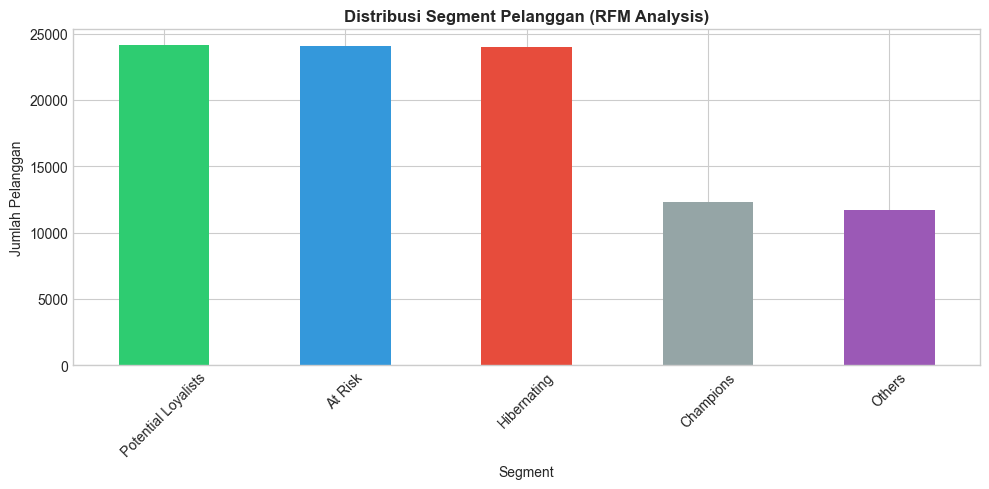

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74,2,1,3,213,Hibernating
1,000161a058600d5901f007fab4c27140,410,1,67.41,1,1,2,112,Hibernating
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42,1,1,4,114,Hibernating
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35,1,1,4,114,Hibernating
4,000379cdec625522490c315e70c7a9fb,150,1,107.01,3,1,3,313,Potential Loyalists
5,0004164d20a9e969af783496f3408652,505,1,71.80,1,1,2,112,Hibernating
6,000419c5494106c306a97b5635748086,180,1,49.40,3,1,1,311,Potential Loyalists
7,00046a560d407e99b969756e0b10f282,255,1,166.59,2,1,3,213,Hibernating
8,00050bf6e01e69d5c0fd612f1bcfb69c,346,1,85.23,2,1,2,212,Hibernating
9,000598caf2ef4117407665ac33275130,19,1,1255.71,4,1,4,414,Potential Loyalists


In [11]:
ref_date = orders_delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = orders_delivered.merge(
    order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id'
).groupby('customer_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (ref_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

# Binning RFM (Manual Grouping)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 4, labels=[4,3,2,1])
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'].rank(method='first'), 4, labels=[1,2,3,4])
rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

# Klasifikasi pelanggan
def rfm_segment(row):
    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3: return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2: return 'Potential Loyalists'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3: return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2: return 'Hibernating'
    else: return 'Others'
rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)

print('Distribusi Segment RFM:')
print(rfm_df['Segment'].value_counts())

# Visualisasi RFM Segment
fig, ax = plt.subplots(figsize=(10, 5))
rfm_df['Segment'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71','#3498db','#e74c3c','#95a5a6','#9b59b6'])
ax.set_title('Distribusi Segment Pelanggan (RFM Analysis)', fontsize=12, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Jumlah Pelanggan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rfm_df.head(10)

terdapat beberapa kelompok yang telah dibuat untuk RFM analysis dengen penjelasan kelompok sebagai berikut:
1. Champions- Pelanggan paling loyal dengan transaksi terbaru, frekuensi tinggi, dan nilai pembelian besar. Serta, perlu dipertahankan karena paling bernilai.
2. Potential Loyalists- Pelanggan yang baru aktif dan berpotensi menjadi loyal. Dapat ditingkatkan dengan promosi atau program loyalitas.
3. At Risk- Pelanggan yang sebelumnya aktif tetapi sudah lama tidak bertransaksi. Perlu didorong agar kembali melakukan pembelian.
4. Hibernating - Pelanggan dengan aktivitas rendah dan sudah lama tidak bertransaksi. Memiliki keterlibatan yang rendah.
5. Others - Pelanggan dengan pola transaksi sedang atau tidak konsisten. Masih berpotensi untuk dikembangkan.

**Insight:**
-  Sebagian besar pelanggan berada pada segmen “Potential Loyalists”, “At Risk”, dan “Hibernating”, menunjukkan peluang besar untuk mempertahankan dan mengaktifkan kembali pelanggan.
- Jumlah pelanggan pada segmen “Champions” relatif lebih sedikit, menunjukkan basis pelanggan paling loyal masih terbatas.

## Simpan Data untuk Dashboard

In [12]:
# Simpan data agregat untuk dashboard Streamlit
import os
os.makedirs('dashboard', exist_ok=True)
os.makedirs('data', exist_ok=True)

city_analysis.to_csv('dashboard/main_data.csv', index=False)
# category_data.csv dan rfm_data.csv dapat dihasilkan dengan python dashboard/generate_data.py
rfm_df.to_csv('dashboard/rfm_data.csv', index=False)

print('Data berhasil disimpan ke folder dashboard/')

Data berhasil disimpan ke folder dashboard/


## Conclusion

**Kesimpulan Pertanyaan 1:** São Paulo adalah kota dengan volume transaksi tertinggi di Brasil selama 2017–2018. Korelasi antara jumlah order dan persentase ketepatan pengiriman menunjukkan bahwa kota dengan volume tinggi cenderung memiliki performa pengiriman yang konsisten. Implikasinya: fokus penguatan logistik dapat dipertahankan di kota-kota besar, sambil memantau skala pertumbuhan agar ketepatan pengiriman tetap terjaga.

**Kesimpulan Pertanyaan 2:** Hubungan antara review score dan AOV berdasarkan kota bersifat tidak linier dan bervariasi—kota dengan review tertinggi tidak selalu memiliki AOV tertinggi, dan sebaliknya. Kepuasan pelanggan (review) dan nilai transaksi rata-rata (AOV) dipengaruhi oleh faktor yang berbeda per wilayah. **Rekomendasi:** (1) Di kota dengan AOV tinggi, prioritaskan kualitas layanan agar review tetap baik dan churn berkurang. (2) Di kota dengan review tinggi tetapi AOV rendah, pertimbangkan strategi upsell atau promosi untuk meningkatkan nilai order tanpa mengorbankan kepuasan. (3) Gunakan analisis per kota (dan per state) untuk menyesuaikan strategi pemasaran dan operasional secara granular.

**Analisis lanjutan:** Segmentasi RFM dan analisis geospatial melengkapi gambaran—RFM membantu mengidentifikasi segmen pelanggan (Champions, At Risk, Hibernating, dll.) untuk strategi retensi dan aktivasi, sementara peta geospatial memvisualisasikan distribusi volume, ketepatan pengiriman, dan review score per kota di Brasil.